In [1]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import numpy as np
# from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
import seaborn as sns
# from joblib import Parallel, delayed
import re
import os
from itertools import combinations
# from statsmodels.stats.multitest import multipletests

plt.rcParams["font.family"] = "Arial"


In [ ]:
# Define mappings

model_map = {
    "Qwen2.5-3B-Instruct": "Q3B",
    # "NACC-3B": "LUNAR-OS-SCe",
    # "NACC-3B-SCE": "LUNAR-OS",
    # "NACC-3B-OS": "LUNAR-SCe",
    "NACC-3B-OS-SCE": "LUNAR",
    "Qwen2.5-7B-Instruct": "Q7B",
}

# Load the data

In [3]:
nifd_path = Path('/projectnb/vkolagrp/projects/adrd_foundation_model/results/NIFD/test_etpr')
nacc_path = Path('/projectnb/vkolagrp/projects/adrd_foundation_model/results/NACC/test_etpr')
adni_path = Path('/projectnb/vkolagrp/projects/adrd_foundation_model/results/ADNI/test_etpr')
ppmi_path = Path('/projectnb/vkolagrp/projects/adrd_foundation_model/results/PPMI/test_etpr')
brainlat_path = Path('/projectnb/vkolagrp/projects/adrd_foundation_model/results/brainlat/test_etpr')

In [4]:
def option_string_to_dict(options):
    # The option string is randomized (e.g. NC is not always option A). We need to break down the 
    # options and look at the text (e.g. MCI), not just the letter that identifies them in a particular question
    pattern = r"([A-Z])\. ([^\n]+)"
    matches = re.findall(pattern, options)
    return {key: value for key, value in matches}

def load_answers(dir_path, dataset_name):
    # load all parquet files from the directory, stack them into a pandas datafame
    # this only reads the participant ID, ground trush answer and the prediction. 
    # Reading only those columns is significantly faster (about 100x) than loading the whole dataframe.
    # Loading everything is very slow because there are extremely long strings (model outputs) in some columns

    fpaths = list(dir_path.rglob('*.parquet'))

    dfs = []

    cols_to_read = ['ID','ground_truth','prediction','ground_truth_text','options'] #, 'generated_text']

    for fpath in tqdm(fpaths):

        model = fpath.parent.name.split('-',3)[-1] 
        benchmark = fpath.parent.parent.name.split('_',1)[-1].upper()

        df = pd.read_parquet(fpath,columns=cols_to_read)
    
        df = df.assign(model=model, benchmark=benchmark)

        df['correct'] = (df['ground_truth'] == df['prediction']).astype(int)

        df['prediction_text'] = df.apply(lambda row: option_string_to_dict(row['options']).get(row['prediction'],'invalid'),axis=1)

        dfs.append(df)

    df = pd.concat(dfs)
    df['dataset'] = dataset_name

    # make these columns Categorical
    group_cols = ["dataset", "benchmark", "model", "ground_truth_text", 'prediction_text']
    for col in group_cols:
        df[col] = pd.Categorical(df[col])

    # keep only the models we actually care about
    df = df[df['model'].isin(list(model_map.keys()))]
    
    # df = df[df['model'].isin(['Qwen2.5-3B-Instruct','Qwen2.5-7B-Instruct','NACC-3B','NACC-3B-OS','NACC-3B-SCE','NACC-3B-OS-SCE'])]

    return df


The `dataset_name` parameter will be used in the results dataset to identify which dataset the data came from

In [5]:
nacc_res = load_answers(nacc_path,dataset_name='NACC')

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:11<00:00,  1.45s/it]


In [6]:
len(nacc_res)

893640

In [7]:
# nacc_res[nacc_res['prediction_text'] == "invalid"]['model'].value_counts()

In [8]:
nacc_res.prediction_text.unique()

['Alzheimer's disease (AD)', 'Not applicable (no cognitive impairment)', 'Vascular brain injury or vascular dementia in..., 'Psychiatric conditions including schizophreni..., 'Lewy body disease (LBD)', 'Systemic and environmental factors including ..., 'Other (Multiple system atrophy, Essential tre..., 'Frontotemporal lobar degeneration and its var..., 'invalid']
Categories (9, object): ['Alzheimer's disease (AD)', 'Frontotemporal lobar degeneration and its var..., 'Lewy body disease (LBD)', 'Not applicable (no cognitive impairment)', ..., 'Psychiatric conditions including schizophreni..., 'Systemic and environmental factors including ..., 'Vascular brain injury or vascular dementia in..., 'invalid']

In [9]:
brainlat_res = load_answers(brainlat_path,dataset_name='BrainLat')

100%|██████████| 8/8 [00:00<00:00, 25.37it/s]


In [10]:
ppmi_res = load_answers(ppmi_path,dataset_name='PPMI')

100%|██████████| 8/8 [00:00<00:00, 39.10it/s]


In [11]:
nifd_res = load_answers(nifd_path,dataset_name='NIFD')

100%|██████████| 8/8 [00:00<00:00, 50.09it/s]


In [12]:
adni_res = load_answers(adni_path,dataset_name='ADNI')

100%|██████████| 8/8 [00:00<00:00, 16.60it/s]


In [13]:
# concatenate everything in a tall format dataframe

results_df = pd.concat(
    [
        adni_res,
        brainlat_res,
        nifd_res,
        nacc_res,
        ppmi_res
    ]
).reset_index(drop=True)

In [14]:
results_df['dataset_raw'] = results_df['dataset']

# results_df['dataset'] = results_df['dataset'].replace(
#     {
#         'ADNI':'Other',
#         'BrainLat':'Other',
#         'NIFD':'Other',
#         'PPMI':'Other',
#     }
# )

In [15]:
results_df.sample(3)

,ID,ground_truth,prediction,ground_truth_text,options,model,benchmark,correct,prediction_text,dataset,dataset_raw
937587,NACC127289,B,E,Not applicable (no cognitive impairment),A. Systemic and environmental factors includin...,Qwen2.5-3B-Instruct,ETPR,0,"Other (Multiple system atrophy, Essential trem...",NACC,NACC
180509,NACC502084,A,H,Alzheimer's disease (AD),A. Alzheimer's disease (AD)\nB. Other (Multipl...,Qwen2.5-7B-Instruct,ETPR,0,Vascular brain injury or vascular dementia inc...,NACC,NACC
295848,NACC848619,G,G,Not applicable (no cognitive impairment),A. Systemic and environmental factors includin...,NACC-3B-OS-SCE,ETPR,1,Not applicable (no cognitive impairment),NACC,NACC


In [16]:
results_df["trial"] = results_df.index
results_df.head()

,ID,ground_truth,prediction,ground_truth_text,options,model,benchmark,correct,prediction_text,dataset,dataset_raw,trial
0,6234,A,D,Not applicable (no cognitive impairment),A. Not applicable (no cognitive impairment)\nB...,Qwen2.5-7B-Instruct,ETPR,0,Vascular brain injury or vascular dementia inc...,ADNI,ADNI,0
1,6234,A,G,Not applicable (no cognitive impairment),A. Not applicable (no cognitive impairment)\nB...,Qwen2.5-7B-Instruct,ETPR,0,Alzheimer's disease (AD),ADNI,ADNI,1
2,6234,A,G,Not applicable (no cognitive impairment),A. Not applicable (no cognitive impairment)\nB...,Qwen2.5-7B-Instruct,ETPR,0,Alzheimer's disease (AD),ADNI,ADNI,2
3,6234,A,G,Not applicable (no cognitive impairment),A. Not applicable (no cognitive impairment)\nB...,Qwen2.5-7B-Instruct,ETPR,0,Alzheimer's disease (AD),ADNI,ADNI,3
4,6234,A,G,Not applicable (no cognitive impairment),A. Not applicable (no cognitive impairment)\nB...,Qwen2.5-7B-Instruct,ETPR,0,Alzheimer's disease (AD),ADNI,ADNI,4


In [17]:
# ============================================================================
# QUICK CHECK
# ============================================================================

from itertools import combinations

print("=" * 80)
print("CHECKING DATA ALIGNMENT FOR PERMUTATION TESTS")
print("=" * 80)

issues_found = False

for (ds, bench), group in results_df.groupby(["dataset", "benchmark"], observed=True):
    models = sorted(group["model"].unique())
    
    print(f"\n📊 {ds} / {bench}")
    
    for m1, m2 in combinations(models, 2):
        d1 = group[group["model"] == m1].copy()
        d2 = group[group["model"] == m2].copy()
        
        # Sort by ID
        d1_sorted = d1.sort_values('ID').reset_index(drop=True)
        d2_sorted = d2.sort_values('ID').reset_index(drop=True)
        
        # Check if IDs match exactly in the same order
        ids_match = d1_sorted['ID'].equals(d2_sorted['ID'])
        
        # Get differences
        ids1 = set(d1['ID'])
        ids2 = set(d2['ID'])
        only_m1 = ids1 - ids2
        only_m2 = ids2 - ids1
        
        if ids_match:
            print(f"   ✅ {m1} vs {m2}: {len(d1)} samples, perfectly aligned")
        else:
            issues_found = True
            print(f"   ❌ {m1} vs {m2}: MISALIGNED!")
            print(f"      {m1}: {len(d1)} samples")
            print(f"      {m2}: {len(d2)} samples")
            
            if only_m1:
                print(f"      Only in {m1}: {len(only_m1)} IDs")
                if len(only_m1) <= 5:
                    print(f"         {sorted(only_m1)}")
            
            if only_m2:
                print(f"      Only in {m2}: {len(only_m2)} IDs")
                if len(only_m2) <= 5:
                    print(f"         {sorted(only_m2)}")
            
            # Check if same IDs but different order
            if ids1 == ids2 and not ids_match:
                print(f"      ⚠️  SAME IDs but DIFFERENT ORDER - will cause wrong pairing!")

print("\n" + "=" * 80)
if issues_found:
    print("❌ ALIGNMENT ISSUES FOUND - PERMUTATION TESTS MAY BE INVALID!")
    print("   See fix below...")
else:
    print("✅ ALL DATA PROPERLY ALIGNED - PERMUTATION TESTS ARE VALID")
print("=" * 80)

CHECKING DATA ALIGNMENT FOR PERMUTATION TESTS

📊 ADNI / ETPR
   ✅ NACC-3B vs NACC-3B-OS: 5295 samples, perfectly aligned
   ✅ NACC-3B vs NACC-3B-OS-SCE: 5295 samples, perfectly aligned
   ✅ NACC-3B vs NACC-3B-SCE: 5295 samples, perfectly aligned
   ✅ NACC-3B vs Qwen2.5-3B-Instruct: 5295 samples, perfectly aligned
   ✅ NACC-3B vs Qwen2.5-7B-Instruct: 5295 samples, perfectly aligned
   ✅ NACC-3B-OS vs NACC-3B-OS-SCE: 5295 samples, perfectly aligned
   ✅ NACC-3B-OS vs NACC-3B-SCE: 5295 samples, perfectly aligned
   ✅ NACC-3B-OS vs Qwen2.5-3B-Instruct: 5295 samples, perfectly aligned
   ✅ NACC-3B-OS vs Qwen2.5-7B-Instruct: 5295 samples, perfectly aligned
   ✅ NACC-3B-OS-SCE vs NACC-3B-SCE: 5295 samples, perfectly aligned
   ✅ NACC-3B-OS-SCE vs Qwen2.5-3B-Instruct: 5295 samples, perfectly aligned
   ✅ NACC-3B-OS-SCE vs Qwen2.5-7B-Instruct: 5295 samples, perfectly aligned
   ✅ NACC-3B-SCE vs Qwen2.5-3B-Instruct: 5295 samples, perfectly aligned
   ✅ NACC-3B-SCE vs Qwen2.5-7B-Instruct: 5295 sa

# Metrics

In [18]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from itertools import combinations
from statsmodels.stats.multitest import multipletests


def _vectorized_metric_calc(y_true, y_pred, label_code, metric):
    """Core vectorized math for both bootstrap and permutation."""
    tp = np.sum((y_pred == label_code) & (y_true == label_code), axis=-1)
    
    if metric == 'precision':
        den = np.sum(y_pred == label_code, axis=-1)
    elif metric == 'recall':
        den = np.sum(y_true == label_code, axis=-1)
    elif metric == 'f1':
        precision_den = np.sum(y_pred == label_code, axis=-1)
        recall_den = np.sum(y_true == label_code, axis=-1)
        precision = np.divide(
            tp, precision_den, out=np.zeros_like(tp, dtype=float), where=precision_den != 0
        )
        recall = np.divide(
            tp, recall_den, out=np.zeros_like(tp, dtype=float), where=recall_den != 0
        )
        with np.errstate(divide='ignore', invalid='ignore'):
            f1 = np.divide(
                2 * precision * recall,
                precision + recall,
                out=np.zeros_like(tp, dtype=float),
                where=(precision + recall) != 0,
            )
        return f1
    else:
        raise ValueError(f"Unknown metric: {metric}")
    return np.divide(tp, den, out=np.zeros_like(tp, dtype=float), where=den != 0)

def _vectorized_macro_metric_calc(y_true, y_pred, label_codes, metric):
    """
    Macro average: mean over labels of per-label metric.
    For bootstrap: returns shape (n_boot,)
    For non-bootstrap: returns scalar (float) if input is (n,)
    """
    label_codes = np.asarray(label_codes, dtype=np.int16)
    if label_codes.size == 0:
        # No labels to average; return zeros shaped like per-label output
        return np.zeros(y_true.shape[0], dtype=float) if y_true.ndim > 1 else 0.0

    acc = None
    label_codes_updated = []
    for lbl in label_codes:
        v = _vectorized_metric_calc(y_true, y_pred, int(lbl), metric)
        # print(v, lbl)
        label_codes_updated.append(lbl)
        if acc is None:
            acc = v.astype(float, copy=False)
        else:
            acc = acc + v
    return acc / float(len(label_codes_updated))

# Bootstrap

In [19]:
def _single_bootstrap_task_macro(group_info, y_true_b, y_pred_b, label_codes, m_type):
    boot_values = _vectorized_macro_metric_calc(y_true_b, y_pred_b, label_codes, m_type)
    low, med, high = np.quantile(boot_values, [0.025, 0.5, 0.975])
    return {
        **group_info,
        "metric": f"macro_{m_type}",
        "mean": float(np.mean(boot_values)),
        "median": float(med),
        "low": float(low),
        "high": float(high),
    }

def optimized_bootstrap_parallel_macro(df, n_boot=1000, seed=42, n_jobs=-1):
    """
    Bootstrap CIs for macro precision/recall per (dataset, benchmark, model),
    where macro is averaged over the labels PRESENT in that group (excluding 'invalid').
    """
    
    # Keep original text columns for grouping
    df_grouped = df[["ID", "trial", "dataset_raw", "dataset", "benchmark", "model", "ground_truth_text", "prediction_text"]].copy()
    
    # Build tasks (2 per group)
    groups = list(df_grouped.groupby(["dataset", "benchmark", "model"], observed=True))
    main_rng = np.random.default_rng(seed)
    all_tasks = []
    
    print(f"Preparing Bootstrap data for {len(groups) * 2} macro tasks...")
    
    for g_id, group in groups:
        # Sort by ID for consistency
        group = group.sort_values(['ID', "trial"]).reset_index(drop=True)
        
        # Get all unique categories for THIS group
        gt_cats = group["ground_truth_text"].astype("category").cat.categories.tolist()
        pred_cats = group["prediction_text"].astype("category").cat.categories.tolist()
        all_cats = sorted(set(gt_cats + pred_cats))
        
        # Ensure 'invalid' is included
        if "invalid" not in all_cats:
            all_cats.append("invalid")
        
        # Create shared categorical dtype for this group
        cat_dtype = pd.CategoricalDtype(categories=all_cats, ordered=False)
        invalid_code = all_cats.index("invalid")
        
        # Encode with consistent mapping
        y_true = group["ground_truth_text"].astype(cat_dtype).cat.codes.astype(np.int16).to_numpy()
        y_pred = group["prediction_text"].astype(cat_dtype).cat.codes.astype(np.int16).to_numpy()
        
        # IMPORTANT: label set is per-group (dataset/benchmark/model)
        label_codes_group = np.unique(np.concatenate([y_true]))#, y_pred]))
        label_codes_group = label_codes_group[label_codes_group != invalid_code]
        
        # If after filtering there are no labels, skip safely
        if label_codes_group.size == 0:
            continue
        
        group_seed = int(main_rng.integers(0, 2**32))
        rng = np.random.default_rng(group_seed)
        indices = rng.integers(0, len(y_true), size=(n_boot, len(y_true)))
        
        y_true_b = y_true[indices]
        y_pred_b = y_pred[indices]
        
        group_info = {"dataset": g_id[0], "benchmark": g_id[1], "model": g_id[2]}
        
        for m_type in ["precision", "recall", "f1"]:
            all_tasks.append((group_info, y_true_b, y_pred_b, label_codes_group, m_type))
    
    print(f"Executing Bootstrap on {len(all_tasks)} tasks across {n_jobs} cores...")
    results = Parallel(n_jobs=n_jobs)(
        delayed(_single_bootstrap_task_macro)(*t) for t in all_tasks
    )
    
    return pd.DataFrame(results)

In [20]:
# Step 1: Compute bootstrap CIs for macro metrics
all_macro_metrics = optimized_bootstrap_parallel_macro(
    results_df, n_boot=1000, seed=42, n_jobs=20
).sort_values(["dataset", "benchmark", "model", "metric"])

Preparing Bootstrap data for 60 macro tasks...
Executing Bootstrap on 90 tasks across 20 cores...


In [21]:
all_macro_metrics[all_macro_metrics['dataset'] == 'NIFD']

,dataset,benchmark,model,metric,mean,median,low,high
56,NIFD,ETPR,NACC-3B,macro_f1,0.503492,0.503908,0.478408,0.526926
54,NIFD,ETPR,NACC-3B,macro_precision,0.871921,0.872299,0.839791,0.904106
55,NIFD,ETPR,NACC-3B,macro_recall,0.387908,0.388044,0.365316,0.410567
59,NIFD,ETPR,NACC-3B-OS,macro_f1,0.550343,0.550269,0.524235,0.576067
57,NIFD,ETPR,NACC-3B-OS,macro_precision,0.911438,0.911620,0.888106,0.933890
58,NIFD,ETPR,NACC-3B-OS,macro_recall,0.403998,0.403656,0.380340,0.429812
62,NIFD,ETPR,NACC-3B-OS-SCE,macro_f1,0.569099,0.569512,0.542035,0.594567
60,NIFD,ETPR,NACC-3B-OS-SCE,macro_precision,0.914408,0.914669,0.892264,0.935726
61,NIFD,ETPR,NACC-3B-OS-SCE,macro_recall,0.419295,0.419466,0.392617,0.445068
65,NIFD,ETPR,NACC-3B-SCE,macro_f1,0.475631,0.475584,0.452872,0.500736


# Permutation testing

In [22]:
# # Trial level permutation
# def _permutation_worker_macro(task, n_perms, seed):
#     rng = np.random.default_rng(seed)
#     yt, yp1, yp2 = task["yt"], task["yp1"], task["yp2"]
#     label_codes, m_type = task["label_codes"], task["metric"]

#     obs1 = _vectorized_macro_metric_calc(yt, yp1, label_codes, m_type)
#     obs2 = _vectorized_macro_metric_calc(yt, yp2, label_codes, m_type)
#     obs_diff = obs1 - obs2
    
#     # print(task['dataset'], task['model1'], task['model2'], obs1, obs2, obs_diff, len(yt), len(yp1), len(yp2))

#     # Vectorized swap across all permutations
#     swap = rng.integers(0, 2, size=(n_perms, len(yt)), dtype=bool)
#     p1 = np.where(swap, yp2, yp1)
#     p2 = np.where(swap, yp1, yp2)

#     null1 = _vectorized_macro_metric_calc(yt, p1, label_codes, m_type)
#     null2 = _vectorized_macro_metric_calc(yt, p2, label_codes, m_type)

#     p_val = float(np.mean(np.abs(null1 - null2) >= np.abs(obs_diff)))

#     out = {k: v for k, v in task.items() if k not in ["yt", "yp1", "yp2", "label_codes"]}
#     out.update(
#         {
#             "p_value": p_val,
#             "observed_diff": float(obs_diff),
#             "metric": f"macro_{m_type}",
#             "obs1": obs1,
#             "obs2": obs2
#         }
#     )
#     return out


# def compute_pairwise_comparisons_macro(df, n_permutations=1000, seed=42, n_jobs=-1):
#     """
#     Permutation tests on macro precision/recall between model pairs within each (dataset, benchmark).
#     Macro labels are computed per (dataset, benchmark) using union(y_true, y_pred1, y_pred2), excluding 'invalid'.
#     Applies BH correction.
#     """

#     # Keep original text columns for grouping
#     df_grouped = df[["ID", "trial", "dataset", "benchmark", "model", "ground_truth_text", "prediction_text"]].copy()

#     tasks = []
#     for (ds, bench), group in df_grouped.groupby(["dataset", "benchmark"], observed=True):
#         # Get all unique categories for THIS dataset/benchmark
#         gt_cats = group["ground_truth_text"].astype("category").cat.categories.tolist()
#         pred_cats = group["prediction_text"].astype("category").cat.categories.tolist()
#         all_cats = sorted(set(gt_cats + pred_cats))
        
#         # Ensure 'invalid' is included
#         if "invalid" not in all_cats:
#             all_cats.append("invalid")
        
#         # Create shared categorical dtype for this dataset/benchmark
#         cat_dtype = pd.CategoricalDtype(categories=all_cats, ordered=False)
#         invalid_code = all_cats.index("invalid")
        
#         # Encode with consistent mapping
#         group_int = pd.DataFrame({
#             "ID": group["ID"],
#             "trial": group["trial"],
#             "model": group["model"],
#             "y_true": group["ground_truth_text"].astype(cat_dtype).cat.codes.astype(np.int16),
#             "y_pred": group["prediction_text"].astype(cat_dtype).cat.codes.astype(np.int16),
#         })
        
#         models = sorted(group_int["model"].unique())

#         for m1, m2 in combinations(models, 2):
#             d1 = group_int[group_int["model"] == m1].sort_values(['ID', 'trial']).reset_index(drop=True)
#             d2 = group_int[group_int["model"] == m2].sort_values(['ID', 'trial']).reset_index(drop=True)
#             if len(d1) != len(d2):
#                 continue  # needs paired alignment

#             yt = d1["y_true"].to_numpy()
#             yp1 = d1["y_pred"].to_numpy()
#             yp2 = d2["y_pred"].to_numpy()

#             # IMPORTANT: label set per dataset/benchmark
#             label_codes = np.unique(np.concatenate([yt]))#, yp1, yp2]))
#             label_codes = label_codes[label_codes != invalid_code]
#             if label_codes.size == 0:
#                 continue

#             for m_type in ["precision", "recall"]:
#                 tasks.append(
#                     {
#                         "dataset": ds,
#                         "benchmark": bench,
#                         "model1": m1,
#                         "model2": m2,
#                         "metric": m_type,
#                         "label_codes": label_codes,
#                         "yt": yt,
#                         "yp1": yp1,
#                         "yp2": yp2,
#                     }
#                 )

#     print(f"Executing Permutation Tests on {len(tasks)} macro tasks...")
#     seeds = np.random.default_rng(seed).integers(0, 2**32, size=len(tasks))
#     results = Parallel(n_jobs=n_jobs)(
#         delayed(_permutation_worker_macro)(tasks[i], n_permutations, int(seeds[i]))
#         for i in range(len(tasks))
#     )
    
#     res_df = pd.DataFrame(results)

#     res_df["p_value_bh"] = np.nan
#     for keys, sub_idx in res_df.groupby(["dataset",  "metric"]).groups.items():
#         p = res_df.loc[sub_idx, "p_value"].to_numpy()
#         _, p_bh, _, _ = multipletests(p, method="fdr_bh")
#         res_df.loc[sub_idx, "p_value_bh"] = p_bh
        
#     res_df["Significant_bh"] = res_df["p_value_bh"] < 0.05

#     return res_df

In [23]:
def _permutation_worker_macro(task, n_perms, seed):
    rng = np.random.default_rng(seed)
    yt, yp1, yp2 = task["yt"], task["yp1"], task["yp2"]
    id_array = task["id_array"]
    label_codes, m_type = task["label_codes"], task["metric"]

    obs1 = _vectorized_macro_metric_calc(yt, yp1, label_codes, m_type)
    obs2 = _vectorized_macro_metric_calc(yt, yp2, label_codes, m_type)
    obs_diff = obs1 - obs2

    # Get unique IDs and create ID-to-index mapping
    unique_ids, id_indices = np.unique(id_array, return_inverse=True)
    n_ids = len(unique_ids)
    
    # Generate ALL permutations at once: shape (n_perms, n_ids)
    swap_ids = rng.integers(0, 2, size=(n_perms, n_ids), dtype=bool)
    
    # Map ID-level swaps to trial-level: shape (n_perms, n_samples)
    swap = swap_ids[:, id_indices] 
    
    # Now we can vectorize again
    p1 = np.where(swap, yp2, yp1)  # Shape: (n_perms, n_samples)
    p2 = np.where(swap, yp1, yp2)

    null1 = _vectorized_macro_metric_calc(yt, p1, label_codes, m_type)
    null2 = _vectorized_macro_metric_calc(yt, p2, label_codes, m_type)

    p_val = float(np.mean(np.abs(null1 - null2) >= np.abs(obs_diff)))

    out = {k: v for k, v in task.items() if k not in ["yt", "yp1", "yp2", "label_codes", "id_array"]}
    out.update({
        "p_value": p_val,
        "observed_diff": float(obs_diff),
        "metric": f"macro_{m_type}",
        "obs1": obs1,
        "obs2": obs2,
    })
    return out


def compute_pairwise_comparisons_macro(df, n_permutations=1000, seed=42, n_jobs=-1):
    """
    Permutation tests on macro precision/recall between model pairs within each (dataset, benchmark).
    Permutation is done at ID level (all trials of an ID swap together).
    """

    df_grouped = df[["ID", "trial", "dataset", "benchmark", "model", "ground_truth_text", "prediction_text"]].copy()

    tasks = []
    for (ds, bench), group in df_grouped.groupby(["dataset", "benchmark"], observed=True):
        gt_cats = group["ground_truth_text"].astype("category").cat.categories.tolist()
        pred_cats = group["prediction_text"].astype("category").cat.categories.tolist()
        all_cats = sorted(set(gt_cats + pred_cats))
        
        if "invalid" not in all_cats:
            all_cats.append("invalid")
        
        cat_dtype = pd.CategoricalDtype(categories=all_cats, ordered=False)
        invalid_code = all_cats.index("invalid")
        
        group_int = pd.DataFrame({
            "ID": group["ID"],
            "trial": group["trial"],
            "model": group["model"],
            "y_true": group["ground_truth_text"].astype(cat_dtype).cat.codes.astype(np.int16),
            "y_pred": group["prediction_text"].astype(cat_dtype).cat.codes.astype(np.int16),
        })
        
        models = sorted(group_int["model"].unique())

        for m1, m2 in combinations(models, 2):
            d1 = group_int[group_int["model"] == m1].sort_values(['ID', 'trial']).reset_index(drop=True)
            d2 = group_int[group_int["model"] == m2].sort_values(['ID', 'trial']).reset_index(drop=True)
            if len(d1) != len(d2):
                continue

            yt = d1["y_true"].to_numpy()
            yp1 = d1["y_pred"].to_numpy()
            yp2 = d2["y_pred"].to_numpy()
            id_array = d1["ID"].to_numpy()  # NEW: pass ID array

            label_codes = np.unique(yt)
            label_codes = label_codes[label_codes != invalid_code]
            if label_codes.size == 0:
                continue

            for m_type in ["precision", "recall", "f1"]:
                tasks.append({
                    "dataset": ds,
                    "benchmark": bench,
                    "model1": m1,
                    "model2": m2,
                    "metric": m_type,
                    "label_codes": label_codes,
                    "yt": yt,
                    "yp1": yp1,
                    "yp2": yp2,
                    "id_array": id_array,  # NEW
                })

    print(f"Executing Permutation Tests on {len(tasks)} macro tasks...")
    seeds = np.random.default_rng(seed).integers(0, 2**32, size=len(tasks))
    results = Parallel(n_jobs=n_jobs)(
        delayed(_permutation_worker_macro)(tasks[i], n_permutations, int(seeds[i]))
        for i in range(len(tasks))
    )

    res_df = pd.DataFrame(results)
    # if len(res_df) > 0:
    #     _, res_df["p_value_bh"], _, _ = multipletests(res_df["p_value"], method="fdr_bh")
    # else:
    #     res_df["p_value_bh"] = []
        
    res_df["p_value_bh"] = np.nan
    for keys, sub_idx in res_df.groupby(["dataset", "metric"]).groups.items():
        p = res_df.loc[sub_idx, "p_value"].to_numpy()
        _, p_bh, _, _ = multipletests(p, method="fdr_bh")
        res_df.loc[sub_idx, "p_value_bh"] = p_bh
        
    res_df["Significant_bh"] = res_df["p_value_bh"] < 0.05

    return res_df

In [24]:
# Step 2: Compute pairwise permutation comparisons on macro metrics
pairwise_macro = compute_pairwise_comparisons_macro(
    results_df, n_permutations=1000, seed=42, n_jobs=20
).sort_values(["dataset", "benchmark", "metric", "model1", "model2"])

Executing Permutation Tests on 45 macro tasks...


In [25]:
pairwise_macro[pairwise_macro['dataset'] == 'NIFD']

,dataset,benchmark,model1,model2,metric,p_value,observed_diff,obs1,obs2,p_value_bh,Significant_bh
29,NIFD,ETPR,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,macro_f1,0.000,0.202223,0.569012,0.366789,0.000,True
32,NIFD,ETPR,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,macro_f1,0.168,0.030893,0.569012,0.538120,0.168,False
35,NIFD,ETPR,Qwen2.5-3B-Instruct,Qwen2.5-7B-Instruct,macro_f1,0.000,-0.171330,0.366789,0.538120,0.000,True
27,NIFD,ETPR,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,macro_precision,0.000,0.152764,0.914849,0.762085,0.000,True
30,NIFD,ETPR,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,macro_precision,0.032,0.053494,0.914849,0.861354,0.032,True
33,NIFD,ETPR,Qwen2.5-3B-Instruct,Qwen2.5-7B-Instruct,macro_precision,0.000,-0.099269,0.762085,0.861354,0.000,True
28,NIFD,ETPR,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,macro_recall,0.000,0.177376,0.418910,0.241535,0.000,True
31,NIFD,ETPR,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,macro_recall,0.522,0.012934,0.418910,0.405977,0.522,False
34,NIFD,ETPR,Qwen2.5-3B-Instruct,Qwen2.5-7B-Instruct,macro_recall,0.000,-0.164442,0.241535,0.405977,0.000,True


# Latex

In [ ]:
import numpy as np
import pandas as pd

def generate_latex_table_macro(all_metric, model_map, dataset_map=None):
    """
    Builds a LaTeX table for macro_precision / macro_recall from the macro bootstrap output,
    and computes macro_f1 from those.

    Expected columns in all_metric:
      ['dataset','benchmark','model','metric','median','low','high']  (benchmark optional)
    where metric in {'macro_precision','macro_recall'} (or 'macro_precision'/'macro_recall').

    - model_map: dict mapping raw model -> display name
    - dataset_map: optional dict mapping raw dataset -> display name
    """
    df = all_metric.copy()

    # 1) Apply mappings
    df["model"] = df["model"].map(model_map).fillna(df["model"])
    if dataset_map is not None and "dataset" in df.columns:
        df["dataset"] = df["dataset"].map(dataset_map).fillna(df["dataset"])

    # 2) Pivot to get macro metrics as columns for F1 calculation
    idx_cols = ["dataset", "model"]
    # if "benchmark" in df.columns:
    #     idx_cols.insert(1, "benchmark")  # dataset, benchmark, model

    stats = df.pivot_table(
        index=idx_cols,
        columns="metric",
        values=["median", "low", "high"]
    ).reset_index()

    # Flatten multi-index columns: ('median','macro_precision') -> 'macro_precision_median'
    stats.columns = [
        f"{col[1]}_{col[0]}" if col[1] else col[0]
        for col in stats.columns
    ]

    # 3) Calculate macro F1 for median and CI bounds
    # Use the same "compute F1 from precision/recall at each bound" approach you had.
    # for stat in ["median", "low", "high"]:
    #     p = stats[f"macro_precision_{stat}"]
    #     r = stats[f"macro_recall_{stat}"]
    #     stats[f"macro_f1_{stat}"] = np.where((p + r) > 0, 2 * (p * r) / (p + r), 0.0)

    # 4) Optional: set a model sort order (edit as needed)
    model_order = list(model_map.values())
    stats["model"] = pd.Categorical(stats["model"], categories=model_order, ordered=True)
    sort_cols = ["dataset", "model"]
    stats = stats.sort_values(by=sort_cols).reset_index(drop=True)

    # 5) Identify best model per (dataset[, benchmark]) for each metric (highest median)
    metrics = ["macro_precision", "macro_recall", "macro_f1"]
    group_cols = ["dataset"]
    # if "benchmark" in stats.columns:
    #     group_cols.append("benchmark")

    # best_lookup = set()
    # for m in metrics:
    #     idx = stats.groupby(group_cols, observed=False)[f"{m}_median"].idxmax()
    #     for i in idx:
    #         if pd.notna(i):
    #             best_lookup.add((int(i), m))
                
    best_lookup = set()
    second_best_lookup = set()

    for m in metrics:
        col = f"{m}_median"

        # Rank within each (dataset, class), highest value = rank 1
        ranks = stats.groupby(
            group_cols, observed=False
        )[col].rank(method="first", ascending=False)

        # Best (rank == 1)
        best_idx = stats.index[(ranks == 1) & stats[col].notna()]
        for i in best_idx:
            best_lookup.add((i, m))

        # Second best (rank == 2)
        second_idx = stats.index[(ranks == 2) & stats[col].notna()]
        for i in second_idx:
            second_best_lookup.add((i, m))

    # 6) Build LaTeX
    headers = ["Dataset"]
    # if "benchmark" in stats.columns:
    #     headers.append("Benchmark")
    headers += ["Model", "Macro Precision", "Macro Recall", "Macro F1"]

    # colspec = "ll" if "benchmark" in stats.columns else "l"
    colspec = "l"
    colspec += "lccc"  # Model + 3 metrics

    latex_lines = [
        "\\begin{table}[ht]",
        "\\centering",
        "\\small",
        f"\\begin{{tabular}}{{{colspec}}}",
        "\\hline",
        " & ".join(headers) + " \\\\",
        "\\hline"
    ]

    prev_group = None
    for i, row in stats.iterrows():
        # Add midrule when dataset (or dataset+benchmark) changes
        this_group = tuple(row[c] for c in group_cols)
        if prev_group is not None and this_group != prev_group:
            latex_lines.append("\\hline")

        # Display dataset/benchmark only on first row of each group
        ds_disp = row["dataset"] if prev_group is None or row["dataset"] != prev_group[0] else ""
        parts = [ds_disp]

        # if "benchmark" in stats.columns:
        #     bench_disp = row["benchmark"] if prev_group is None or (len(prev_group) > 1 and row["benchmark"] != prev_group[1]) else ""
        #     parts.append(bench_disp)

        parts.append(str(row["model"]))

        formatted_metrics = []
        for m in metrics:
            val_str = f"{row[f'{m}_median']:.3f} [{row[f'{m}_low']:.3f}, {row[f'{m}_high']:.3f}]"
            if (i, m) in best_lookup:
                val_str = f"\\textbf{{{val_str}}}"
            if (i, m) in second_best_lookup:
                val_str = f"\\underline{{{val_str}}}"
            formatted_metrics.append(val_str)

        row_str = " & ".join(parts) + " & " + " & ".join(formatted_metrics) + " \\\\"
        latex_lines.append(row_str)

        prev_group = this_group

    latex_lines.extend(["\\hline", "\\end{tabular}", "\\end{table}"])
    return "\n".join(latex_lines)


In [25]:
latex_output = generate_latex_table_macro(all_macro_metrics, model_map=model_map)#, class_map=class_map)
print(latex_output)

\begin{table}[ht]
\centering
\small
\begin{tabular}{llccc}
\hline
Dataset & Model & Macro Precision & Macro Recall & Macro F1 \\
\hline
ADNI & Q3B & 0.731 [0.717, 0.745] & 0.508 [0.496, 0.520] & 0.539 [0.525, 0.553] \\
 & LUNAR-OS-SCe & 0.811 [0.800, 0.822] & \underline{0.739 [0.727, 0.750]} & \underline{0.773 [0.762, 0.783]} \\
 & LUNAR-OS & 0.815 [0.804, 0.826] & \textbf{0.756 [0.744, 0.768]} & \textbf{0.783 [0.772, 0.794]} \\
 & LUNAR-SCe & \underline{0.848 [0.836, 0.859]} & 0.659 [0.645, 0.672] & 0.739 [0.727, 0.751] \\
 & LUNAR & \textbf{0.855 [0.844, 0.866]} & 0.642 [0.629, 0.655] & 0.731 [0.720, 0.743] \\
 & Q7B & 0.791 [0.780, 0.803] & 0.665 [0.652, 0.677] & 0.705 [0.692, 0.717] \\
\hline
BrainLat & Q3B & 0.471 [0.447, 0.494] & 0.338 [0.323, 0.354] & 0.337 [0.322, 0.353] \\
 & LUNAR-OS-SCe & 0.536 [0.520, 0.551] & \underline{0.427 [0.411, 0.443]} & \underline{0.439 [0.423, 0.455]} \\
 & LUNAR-OS & 0.544 [0.527, 0.560] & \textbf{0.449 [0.431, 0.466]} & \textbf{0.463 [0.445, 0.48

# Circular bar plot

In [90]:
sns.set_style("whitegrid")

fontsize = 7

table_positions = {
    'macro_precision': {
        'NIFD': (-0.25, 1.07),
        'NACC': (-0.5, 0.9),
        'BrainLat': (0.34, 0.98),
        'ADNI': (0.3, 1.2),
        'PPMI': (-0.15, 0.92),
        'Other': (0.15, 1.08),
    },
    'macro_recall': {
        'NIFD': (-0.25, 0.9),
        'NACC': (-0.5, 0.9),
        'BrainLat': (0.34, 0.98),
        'ADNI': (0.3, 1.1),
        'PPMI': (-0.15, 0.92),
        'Other': (0.15, 1.08),
    },
    'macro_f1': {
        'NIFD': (-0.25, 0.9),
        'NACC': (-0.5, 0.9),
        'BrainLat': (0.34, 0.98),
        'ADNI': (0.3, 1.1),
        'PPMI': (-0.15, 0.92),
        'Other': (0.15, 1.08),
    }
}

value_label_offsets = {
    'NIFD':     {'r_offset': 0.06, 'theta_offset': 0.0},
    'NACC':     {'r_offset': 0.12, 'theta_offset': -0.2},
    'BrainLat': {'r_offset': 0.15, 'theta_offset': 0.02},
    'ADNI':     {'r_offset': 0.14, 'theta_offset': -0.03},
    'PPMI':     {'r_offset': 0.14, 'theta_offset': 0.1},
}


def get_significance_marker(p_value):
    if isinstance(p_value, str):
        return p_value
    if pd.isna(p_value):
        return ""
    if p_value < 0.0001:
        return "****"
    elif p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    elif p_value <= 1.0:
        return "ns"
    else:
        return str(p_value)


def plot_macro_circular(
    all_metrics, pairwise_pvalues,
    model_map,
    output_dir=".",
    show_all_comparisons=False,
    p_threshold=0.05,
    model_order=("Q3B", "LUNAR", "Q7B"),
    dataset_order=("NACC", "Other"),
    filename="fig3_macro_circular_bar_plot_sidebyside",
    metrics=("macro_precision", "macro_recall"),
    figsize=(2.3, 2.3)
):
    """
    Plot MACRO metrics as circular/radial bar plots.
    Works for any number of metrics (1 or 2), one subplot per metric,
    mirroring the pattern used in plot_classwise_with_pvalues.

    all_metrics: output of optimized_bootstrap_parallel_macro(...)
      columns: dataset, benchmark(optional), model, metric, median, low, high

    pairwise_pvalues: output of compute_pairwise_comparisons_macro(...)
      columns: dataset, benchmark(optional), model1, model2, metric, p_value, p_value_bh, observed_diff
    """
    metrics = list(metrics)
    n_metrics = len(metrics)
    metric_names = {"macro_precision": "Macro Precision", "macro_recall": "Macro Recall", "macro_f1": "Macro F1"}

    # -----------------------
    # Apply mappings
    # -----------------------
    df = all_metrics.copy()
    df["model_abbrev"] = df["model"].map(model_map).fillna(df["model"])

    pv = pairwise_pvalues.copy()
    pv["model1_abbrev"] = pv["model1"].map(model_map).fillna(pv["model1"])
    pv["model2_abbrev"] = pv["model2"].map(model_map).fillna(pv["model2"])

    # Keep only requested metrics
    df = df[df["metric"].isin(metrics)].copy()
    pv = pv[pv["metric"].isin(metrics)].copy()

    has_benchmark = ("benchmark" in df.columns) and ("benchmark" in pv.columns)

    datasets_present = sorted(df["dataset"].unique())
    datasets = [d for d in dataset_order if d in datasets_present] or datasets_present

    models = list(model_order)
    palette = dict(zip(models, sns.color_palette("colorblind", n_colors=len(models))))

    # -----------------------
    # Create figure: 1 polar subplot per metric, laid out side-by-side.
    # Figure width scales with n_metrics, matching plot_classwise_with_pvalues
    # which scales height with n_metrics (rows). Here metrics are columns so
    # we scale width instead.
    # -----------------------
    
    fig, axes = plt.subplots(
        1, n_metrics,
        figsize=figsize,
        subplot_kw={"projection": "polar"},
        squeeze=False,   # always shape (1, n_metrics) — mirrors squeeze=False in classwise
    )

    for metric_idx, metric in enumerate(metrics):
        ax = axes[0, metric_idx]   # row 0, column metric_idx

        n_groups = len(datasets)
        group_width = 2 * np.pi / n_groups
        dataset_gap = group_width * 0.1
        bar_width = (group_width - dataset_gap) / len(models) * 0.95

        dataset_centers = {}

        # -----------------------
        # Plot bars
        # -----------------------
        for group_idx, dataset in enumerate(datasets):
            panel = df[(df["dataset"] == dataset) & (df["metric"] == metric)].copy()

            if has_benchmark and "benchmark" in panel.columns and panel["benchmark"].nunique() > 1:
                first_bench = sorted(panel["benchmark"].unique())[0]
                panel = panel[panel["benchmark"] == first_bench]

            base_angle = group_idx * group_width + dataset_gap / 2

            for model_idx, model in enumerate(models):
                mdata = panel[panel["model_abbrev"] == model]

                if len(mdata) == 0:
                    val, low, high = 0.0, 0.0, 0.0
                else:
                    val = float(mdata["median"].iloc[0])
                    low = float(mdata["low"].iloc[0])
                    high = float(mdata["high"].iloc[0])

                err_low = val - low
                err_high = high - val

                theta = base_angle + model_idx * bar_width + bar_width / 2

                # Label only in the first metric subplot (mirrors classwise: label in last col only)
                label = model if (metric_idx == 0 and group_idx == 0) else ""

                ax.bar(
                    theta, val,
                    width=bar_width * 0.98,
                    bottom=0.0,
                    color=palette[model],
                    alpha=0.8,
                    label=label,
                    edgecolor='white',
                    linewidth=0.5
                )

                ax.errorbar(
                    theta, val,
                    yerr=[[err_low], [err_high]],
                    fmt='none',
                    ecolor='black',
                    capsize=3,
                    capthick=0.6,
                    elinewidth=0.6
                )

                if val > 0.1:
                    if val > 0.1:
                        offsets = value_label_offsets.get(dataset, {'r_offset': 0.08, 'theta_offset': 0.0})
                        ax.text(
                            theta + offsets['theta_offset'],
                            val + err_high + offsets['r_offset'],
                            f"{val:.2f}",
                            ha='center', va='bottom',
                            fontsize=fontsize,
                            rotation=0,
                            fontweight='bold'
                        )

            group_center = base_angle + (len(models) * bar_width) / 2
            dataset_centers[dataset] = group_center

        # -----------------------
        # Dataset labels and statistics tables
        # -----------------------
        for dataset, theta in dataset_centers.items():
            ax.text(
                theta, 1.25, dataset,
                ha='center', va='center',
                fontsize=fontsize, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.7)
            )

            psubset = pv[
                (pv["dataset"] == dataset) &
                (pv["metric"] == metric)
            ].copy()

            if has_benchmark and "benchmark" in psubset.columns:
                panel = df[(df["dataset"] == dataset) & (df["metric"] == metric)]
                if panel["benchmark"].nunique() == 1:
                    b = panel["benchmark"].iloc[0]
                    psubset = psubset[psubset["benchmark"] == b]

            if len(psubset) > 0:
                table_lines = []
                for _, prow in psubset.iterrows():
                    m1 = prow["model1_abbrev"]
                    m2 = prow["model2_abbrev"]
                    pval = float(prow["p_value_bh"])
                    sig_marker = get_significance_marker(pval)
                    if (m1 in models) and (m2 in models):
                        table_lines.append(f"{m1}-{m2}: {sig_marker}")

                if table_lines:
                    theta_offset, radius = table_positions.get(metric, {}).get(dataset, (0.15, 1.08))
                    table_text = "\n".join(table_lines[:6])
                    ax.text(
                        theta + theta_offset, radius,
                        table_text,
                        ha='center', va='bottom',
                        fontsize=fontsize - 2,
                    
                        fontfamily='monospace',
                        bbox=dict(boxstyle='round,pad=0.3',
                                  facecolor='white',
                                  edgecolor='gray',
                                  alpha=0.95,
                                  linewidth=0.8)
                    )

        # -----------------------
        # Formatting
        # -----------------------
        ax.set_ylim(0, 1.28)
        ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=fontsize-2)
        ax.set_xticks([])
        ax.grid(True, alpha=0.35, axis='y')
        ax.grid(False, axis='x')

        for i in range(n_groups):
            sep_theta = i * group_width
            ax.plot([sep_theta, sep_theta], [0, 1.28], 'k--', alpha=0.3, linewidth=1.5)

        if "macro_f1" not in metrics:
            ax.set_title(metric_names.get(metric, metric), fontsize=fontsize, fontweight='bold', pad=20)

    # -----------------------
    # Shared legend — placed below the figure, mirroring plot_classwise_with_pvalues
    # -----------------------
    handles = [
        plt.Rectangle((0, 0), 1, 1, fc=palette[m], alpha=0.8, label=m)
        for m in models
    ]
    fig.legend(
        handles=handles,
        title="Model",
        title_fontsize=fontsize,
        loc="lower center",
        ncol=len(models),
        bbox_to_anchor=(0.5, -0.03),
        frameon=True,
        fontsize=fontsize
    )

    plt.tight_layout(rect=[0, 0.06, 1, 1])

    os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, f"../figures/{filename}.pdf")
    plt.savefig(out_path, bbox_inches="tight", dpi=300)
    print(f"Saved {out_path}")
    # plt.close()


Saved ./../figures/fig3_macro_circular_bar_plot_sidebyside_id_level.pdf


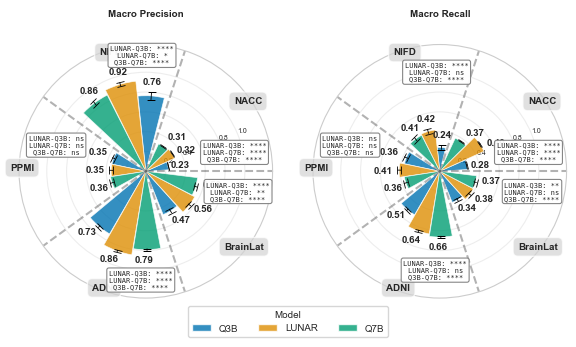

In [92]:
dataset_order = ['NACC', 'NIFD', 'PPMI', 'ADNI', 'BrainLat']
# Example call (macro)
plot_macro_circular(
    all_metrics=all_macro_metrics,          # from optimized_bootstrap_parallel_macro(...)
    pairwise_pvalues=pairwise_macro,        # from compute_pairwise_comparisons_macro(...)
    model_map=model_map,
    output_dir=".",
    show_all_comparisons=True,
    p_threshold=1,  # set <0.05 to filter
    dataset_order=dataset_order,
    filename="fig3_macro_circular_bar_plot_sidebyside_id_level",
    metrics=("macro_precision", "macro_recall"),
    figsize=(6, 3.2)
    # filename="fig3_macro_circular_bar_plot_sidebyside_id_level_f1",
    # metrics=["macro_f1"],
    # figsize=(3.2, 3.2)
)